In [2]:
# Importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
import seaborn as sns

from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')
%matplotlib inline

from sklearn import datasets

from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift
from sklearn.cluster import DBSCAN

from scipy.cluster.hierarchy import linkage
from yellowbrick.cluster import SilhouetteVisualizer

import warnings
warnings.filterwarnings('ignore')
warnings.warn('DelftStack')
warnings.warn('Do not show this message')

In [10]:
# Datos de ejemplo de clases
df = pd.DataFrame() # datos
x = [10, 8, 34, 9, 46, 68]
y = [4, 99, 44, 50, 77, 30]

df['X'] = x
df['Y'] = y

# nuevos datos
new = pd.DataFrame() 
new['X'] = [20, 20, 50]
new['Y'] = [15, 80, 50]

print(df)
print(new)

# Dataframe para los resultados
df2=df
# Dataframe para resultados de las predicciones
new2=new

    X   Y
0  10   4
1   8  99
2  34  44
3   9  50
4  46  77
5  68  30
    X   Y
0  20  15
1  20  80
2  50  50


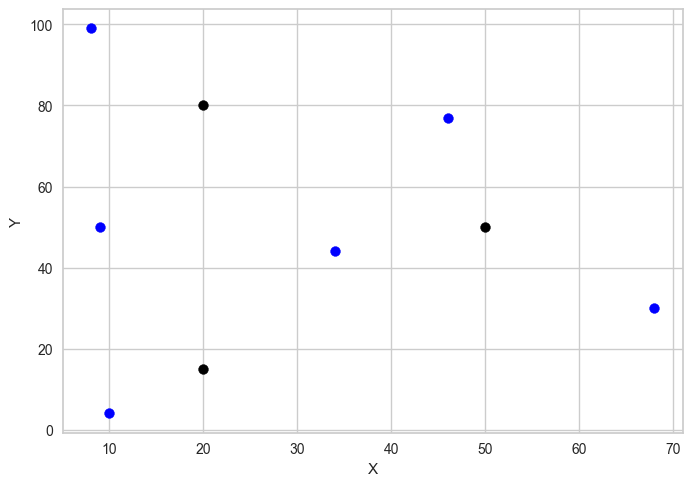

In [11]:
# Graficos de dispersión de datos originales y nuevos
plt.scatter(df['X'], df['Y'], s = 50, c = 'blue')
plt.scatter(new['X'], new['Y'], s = 50, c = 'black')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [12]:
# Distancia euclidiana de los items 
dist1 = pairwise_distances(X= df,  metric ='euclidean')
print(dist1)
print(dist1.mean())
print(np.percentile(dist1, [25, 50, 75]))

# Definir colores para 3 grupos
colors = {0: "red", 1: "blue", 2: "green"}

[[ 0.         95.0210503  46.64761516 46.01086828 81.39410298 63.56099433]
 [95.0210503   0.         60.8358447  49.01020302 43.9089968  91.43850392]
 [46.64761516 60.8358447   0.         25.70992026 35.11409973 36.76955262]
 [46.01086828 49.01020302 25.70992026  0.         45.80392996 62.29767251]
 [81.39410298 43.9089968  35.11409973 45.80392996  0.         51.89412298]
 [63.56099433 91.43850392 36.76955262 62.29767251 51.89412298  0.        ]]
46.412082086679696
[35.11409973 46.32924172 62.29767251]


In [13]:
# Uso del método MeanShift
# Se debe entregar el ancho de banda del kernel

clust_meanshift = MeanShift(bandwidth=40).fit(df)
y_ms=clust_meanshift.labels_
print(y_ms)
print(clust_meanshift.cluster_centers_)

# agregar resultado de MeanShift a dataframe
df2['MS'] = y_ms
print(df2)

## Predicir nuevos datos
new_ms=clust_meanshift.predict(new.to_numpy().tolist()) 

# agregar predicción
new2['MS'] = new_ms
print(new2)

# Definir colores a los puntos predichos
color_new_ms = new2.MS.map(colors)

# Ejercicio: Modificar el bandwidth

[1 2 0 0 0 0]
[[39.25 50.25]
 [10.    4.  ]
 [ 8.   99.  ]]
    X   Y  MS
0  10   4   1
1   8  99   2
2  34  44   0
3   9  50   0
4  46  77   0
5  68  30   0
    X   Y  MS
0  20  15   1
1  20  80   2
2  50  50   0


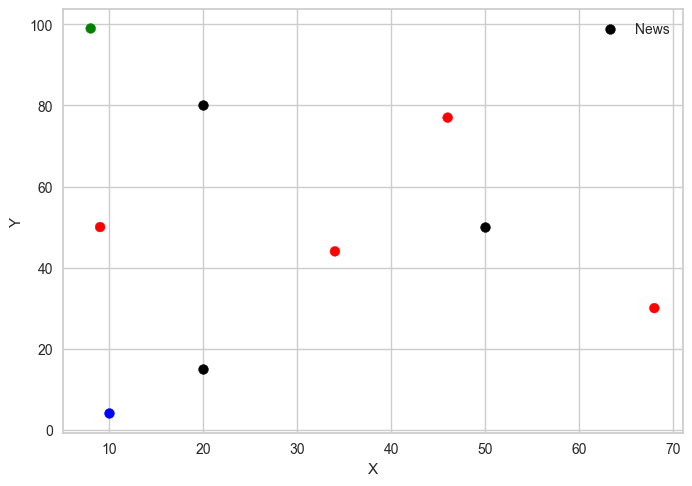

In [14]:
# colores para MeanShift
color_ms = df2.MS.map(colors)

# Grafica de los grupos formados
plt.scatter(df['X'], df['Y'], s = 50, c = color_ms)
plt.scatter(new['X'], new['Y'], s = 50, c = 'black', label="News")

plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

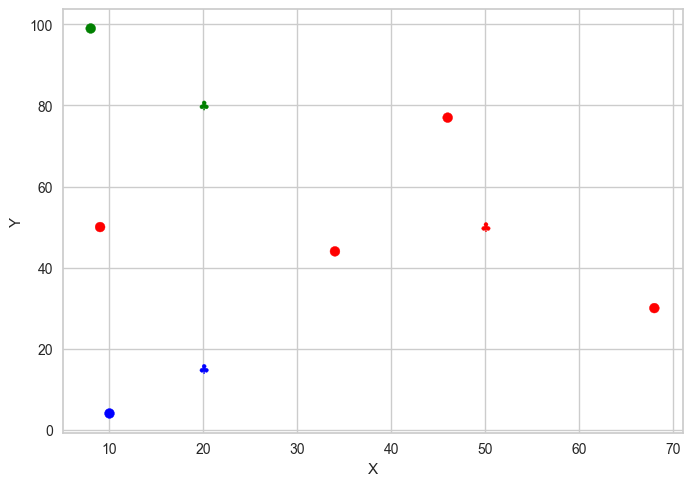

In [15]:

# Grafica de los grupos formados
plt.scatter(df['X'], df['Y'], s = 50, c = color_ms)
plt.scatter(new['X'], new['Y'], s = 50, c = color_new_ms, marker = r'$\clubsuit$')

plt.xlabel('X')
plt.ylabel('Y')
plt.show()

# ¿Que pasará si se escalan las variables? Realizar como ejercicio.

In [16]:
#########################################################
## Metodología DBScan

clust_DBScan = DBSCAN(eps=40, min_samples=2).fit(df)
y_dbs=clust_DBScan.labels_
print(y_dbs)
df2['DBS'] = y_dbs # agregar resultado de MeanShift a dataframe
print(df2)

## Predicir nuevos datos
new_dbs=clust_DBScan.fit_predict(new.to_numpy().tolist())
new2['DBS']=new_dbs

print(new2)

## Ejercicio: Variar los hiperparámetros

[-1 -1  0  0  0  0]
    X   Y  MS  DBS
0  10   4   1   -1
1   8  99   2   -1
2  34  44   0    0
3   9  50   0    0
4  46  77   0    0
5  68  30   0    0
    X   Y  MS  DBS
0  20  15   1   -1
1  20  80   2   -1
2  50  50   0   -1


In [17]:
# Definir colores para 3 grupos y ruido
colors = {0: "red", 1: "blue", 2: "green", -1:"gray"}
colors

{0: 'red', 1: 'blue', 2: 'green', -1: 'gray'}

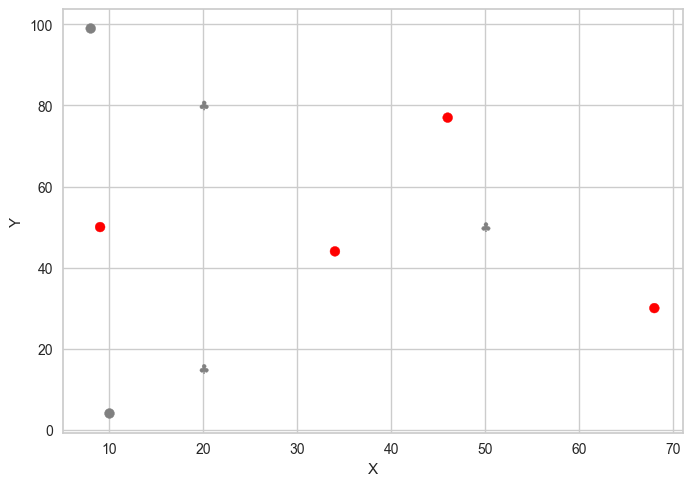

In [18]:
color_dbs = df2.DBS.map(colors)
color_new_dbs = new2.DBS.map(colors)

## Grafica de los clusters
plt.scatter(df['X'], df['Y'], s = 50, c = color_dbs, label = 'Cluster 1')
plt.scatter(new['X'], new['Y'], s = 50, c = color_new_dbs, marker = r'$\clubsuit$' )

plt.xlabel('X')
plt.ylabel('Y')
plt.show()

,Sepal_length,Sepal_width,Petal_length,Petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


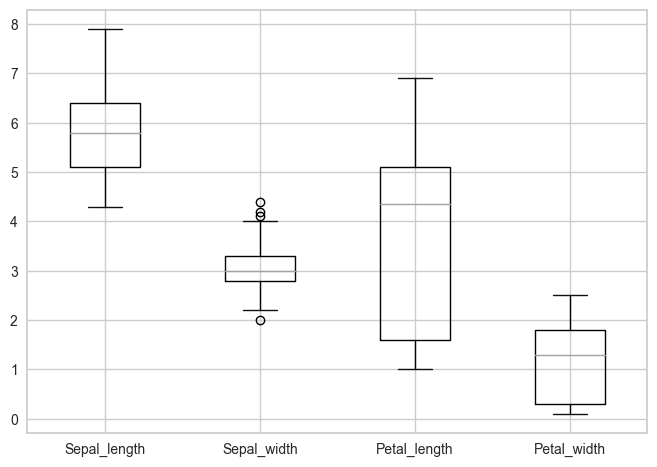

In [19]:
####################################################
## Aplicar las metodologias a la base iris

# Base de datos iris
iris = datasets.load_iris()

X = pd.DataFrame(iris.data)
y = iris.target

X.columns = ['Sepal_length', 'Sepal_width', 'Petal_length', 'Petal_width']

X.boxplot()
round(X.describe(),2)

,Sepal_length,Sepal_width,Petal_length,Petal_width
count,150.00,150.00,150.00,150.00
mean,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.87,-2.43,-1.57,-1.45
25%,-0.90,-0.59,-1.23,-1.18
50%,-0.05,-0.13,0.34,0.13
75%,0.67,0.56,0.76,0.79
max,2.49,3.09,1.79,1.71


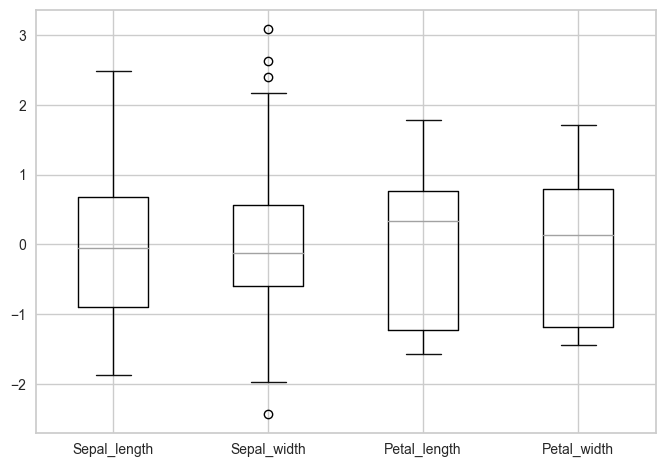

In [20]:
# Se recomienda escalar o estandarizar

X2 = pd.DataFrame(scale(X))
X2.columns = ['Sepal_length', 'Sepal_width', 'Petal_length', 'Petal_width']

X2.boxplot()
round(X2.describe(),2)

In [21]:
# Se crea un Dataframe con resultados

df_iris = pd.DataFrame() 
df_iris['Especie'] = y  
df_iris.head(10) # inicialmente solo la etiqueta

,Especie
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [22]:
# Aplicar MeanShift
iris_ms1 = MeanShift(bandwidth=2).fit(X)
iris_ms2 = MeanShift(bandwidth=1).fit(X2)
y_ms1=iris_ms1.labels_
y_ms2=iris_ms2.labels_

# se agregan resultados de meanshift
df_iris['MS1'] = y_ms1
df_iris['MS2'] = y_ms2

print(y_ms1)
print(y_ms2)

print(sum(y_ms1!=y_ms2))

print(iris_ms1.cluster_centers_)
print(iris_ms2.cluster_centers_)


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 3 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 3 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 3 0 0 0 0 0 0 2 0 0 0 2 0
 0 0 0 0 0 0 2 0 0 2 0 2 0 0 2 0 0 0 0 0 2 0 0 0 2 0 0 0 0 0 0 0 2 2 0 0 0
 0 0]
15
[[6.22111111 2.87777778 4.86777778 1.67333333]
 [5.00784314 3.40980392 1.49215686 0.2627451 ]]
[[ 0.3160462  -0.39574661  0.52475154  0.4396515 ]
 [-1.06560411  0.66731485 -1.30391373 -1.264254  ]
 [ 2.12851559  1.55613014  1.50164482  1.36107679]
 [-1.62768839 -1.74335684 -1.39706395 -1.18381211]]


In [31]:
# Aplicar DBSCAN

iris_dbs1 = DBSCAN(eps=1.50, min_samples=10).fit(X)
iris_dbs2 = DBSCAN(eps=0.75, min_samples=5).fit(X2)
y_dbs1=iris_dbs1.labels_
y_dbs2=iris_dbs2.labels_

# se agregan resultados de dbscan
df_iris['DBS1'] = y_dbs1
df_iris['DBS2'] = y_dbs2

print(y_dbs1)
print(y_dbs2)

print(sum(y_dbs1!=y_dbs2))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]
6


In [32]:
## Resultados

print(df_iris)

print(pd.crosstab(y, y_ms1))
print(pd.crosstab(y, y_ms2))

print(pd.crosstab(y, y_dbs1))
print(pd.crosstab(y, y_dbs2))

     Especie  MS1  MS2  DBS1  DBS2
0          0    1    1     0     0
1          0    1    1     0     0
2          0    1    1     0     0
3          0    1    1     0     0
4          0    1    1     0     0
..       ...  ...  ...   ...   ...
145        2    0    0     1     1
146        2    0    0     1     1
147        2    0    0     1     1
148        2    0    0     1     1
149        2    0    0     1     1

[150 rows x 5 columns]
col_0   0   1
row_0        
0       0  50
1      48   2
2      50   0
col_0   0   1   2  3
row_0               
0       0  49   0  1
1      46   0   0  4
2      40   0  10  0
col_0   0   1
row_0        
0      50   0
1       0  50
2       0  50
col_0  -1   0   1
row_0            
0       2  48   0
1       0   0  50
2       4   0  46


In [33]:
## Calcula de las suma intra 
def sum_intra(df_input, y_hc):
    DW = []
    for n_cluster in range(0, max(y_hc)+1):
        DW_aux = pairwise_distances(X=df_input[y_hc==n_cluster],  metric ='euclidean')
        DW.append(DW_aux.sum())
        return sum(DW)

In [34]:
## W para MeanShift
print(sum_intra(X,  y_ms1))
print(sum_intra(X,  y_ms2))

## W para DBScan: ¿Tiene sentido directamente?
print(sum_intra(X,  y_dbs1))
print(sum_intra(X,  y_dbs2))

13595.220611027835
9024.937295994254
1707.2013542324044
1459.0684254174735


In [36]:
#####################################################
## Visualización a través de componentes principales

# Componentes principales de Iris

pca_pipe1 = make_pipeline(StandardScaler(), PCA()) # con StandardScaler() escala interamente 
pca_pipe2 = make_pipeline(StandardScaler(), PCA())

pca_pipe1.fit(X)  # sin escalar
pca_pipe2.fit(X2) # con datos escalados
# ¿Deberia haber alguna diferencia en los resultados?

# Se extrae el modelo entrenado del pipeline
modelo_pca1 = pca_pipe1.named_steps['pca']
modelo_pca2 = pca_pipe2.named_steps['pca']

print(modelo_pca1.explained_variance_ratio_*100)
print(modelo_pca2.explained_variance_ratio_*100)

print(modelo_pca1.explained_variance_ratio_.cumsum()*100)
print(modelo_pca2.explained_variance_ratio_.cumsum()*100)


# Se combierte el array a dataframe para añadir nombres a los ejes (vectores propios).
print(
pd.DataFrame(
    data    = modelo_pca1.components_,
    columns = X.columns,
    index   = ['PC1', 'PC2', 'PC3', 'PC4']
))

print(
pd.DataFrame(
    data    = modelo_pca2.components_,
    columns = X2.columns,
    index   = ['PC1', 'PC2', 'PC3', 'PC4']
))

[72.96244541 22.85076179  3.66892189  0.51787091]
[72.96244541 22.85076179  3.66892189  0.51787091]
[ 72.96244541  95.8132072   99.48212909 100.        ]
[ 72.96244541  95.8132072   99.48212909 100.        ]
     Sepal_length  Sepal_width  Petal_length  Petal_width
PC1      0.521066    -0.269347      0.580413     0.564857
PC2      0.377418     0.923296      0.024492     0.066942
PC3      0.719566    -0.244382     -0.142126    -0.634273
PC4     -0.261286     0.123510      0.801449    -0.523597
     Sepal_length  Sepal_width  Petal_length  Petal_width
PC1      0.521066    -0.269347      0.580413     0.564857
PC2      0.377418     0.923296      0.024492     0.066942
PC3      0.719566    -0.244382     -0.142126    -0.634273
PC4     -0.261286     0.123510      0.801449    -0.523597


In [37]:
# Proyección de las observaciones de entrenamiento
# ==============================================================================
proyecciones1 = pca_pipe1.transform(X=X)
proyecciones1 = pd.DataFrame(
    proyecciones1,
    columns = ['PC1', 'PC2', 'PC3', 'PC4'],
    index   = X.index
)

proyecciones2 = pca_pipe2.transform(X=X2)
proyecciones2 = pd.DataFrame(
    proyecciones2,
    columns = ['PC1', 'PC2', 'PC3', 'PC4'],
    index   = X2.index
)

print(proyecciones1.head(10))
print(proyecciones2.head(10))

        PC1       PC2       PC3       PC4
0 -2.264703  0.480027  0.127706 -0.024168
1 -2.080961 -0.674134  0.234609 -0.103007
2 -2.364229 -0.341908 -0.044201 -0.028377
3 -2.299384 -0.597395 -0.091290  0.065956
4 -2.389842  0.646835 -0.015738  0.035923
5 -2.075631  1.489178 -0.026968 -0.006608
6 -2.444029  0.047644 -0.335470  0.036776
7 -2.232847  0.223148  0.088695  0.024612
8 -2.334640 -1.115328 -0.145077  0.026859
9 -2.184328 -0.469014  0.253766  0.039899
        PC1       PC2       PC3       PC4
0 -2.264703  0.480027  0.127706 -0.024168
1 -2.080961 -0.674134  0.234609 -0.103007
2 -2.364229 -0.341908 -0.044201 -0.028377
3 -2.299384 -0.597395 -0.091290  0.065956
4 -2.389842  0.646835 -0.015738  0.035923
5 -2.075631  1.489178 -0.026968 -0.006608
6 -2.444029  0.047644 -0.335470  0.036776
7 -2.232847  0.223148  0.088695  0.024612
8 -2.334640 -1.115328 -0.145077  0.026859
9 -2.184328 -0.469014  0.253766  0.039899


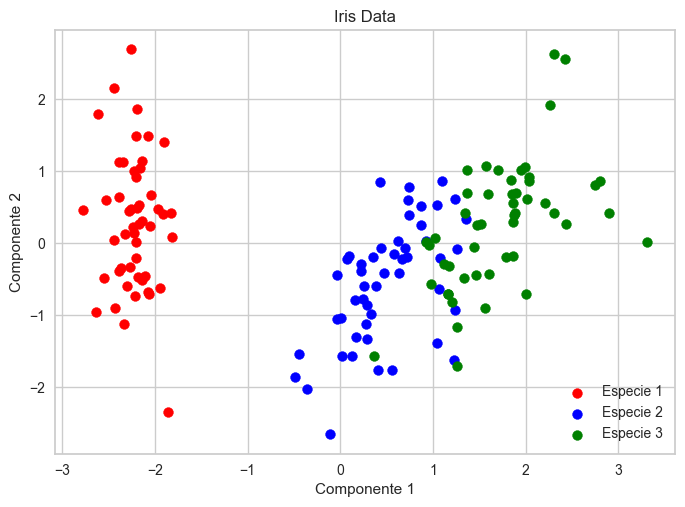

In [38]:
# Visualizacion con las primeras 2 componentes principales 
# Especies originales

plt.scatter(proyecciones1['PC1'][y == 0], proyecciones1['PC2'][y == 0], s = 50, c = 'red', label = 'Especie 1')
plt.scatter(proyecciones1['PC1'][y == 1], proyecciones1['PC2'][y == 1], s = 50, c = 'blue', label = 'Especie 2')
plt.scatter(proyecciones1['PC1'][y == 2], proyecciones1['PC2'][y == 2], s = 50, c = 'green', label = 'Especie 3')

plt.title('Iris Data')
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.show()

In [39]:
# colores para Grupos
colors = {-1: "gray", 0: "red", 1: "blue", 2: "green", 3: "yellow", 4: "violet"}

color_ms1 = df_iris.MS1.map(colors)
color_ms2 = df_iris.MS2.map(colors)
color_dbs1 = df_iris.DBS1.map(colors)
color_dbs2 = df_iris.DBS2.map(colors)

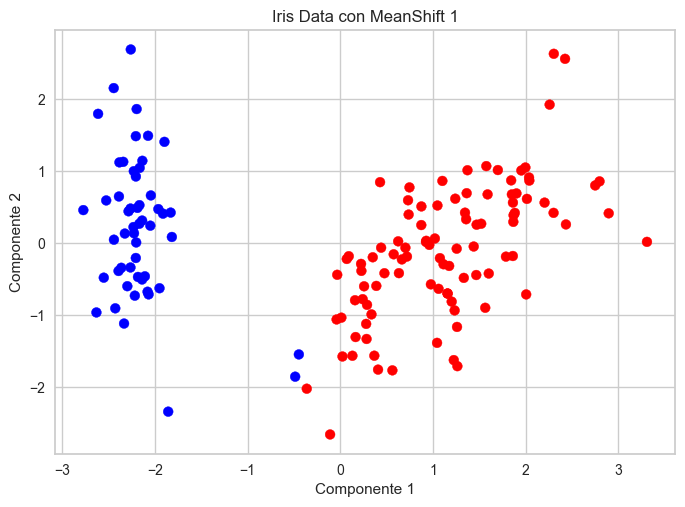

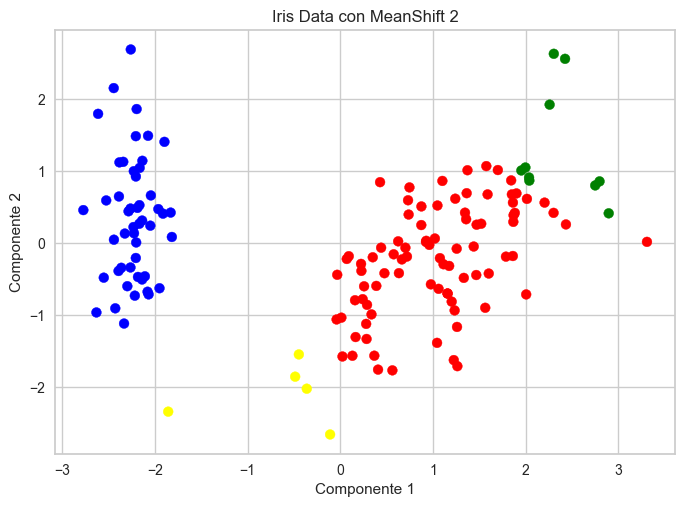

In [40]:
# Visualizacion con las primeras 2 componentes principales 
# Grupos formados con MeanShift

plt.scatter(proyecciones1['PC1'], proyecciones1['PC2'], s = 50, c = color_ms1)
plt.title('Iris Data con MeanShift 1')
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

plt.scatter(proyecciones1['PC1'], proyecciones1['PC2'], s = 50, c = color_ms2)
plt.title('Iris Data con MeanShift 2')
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

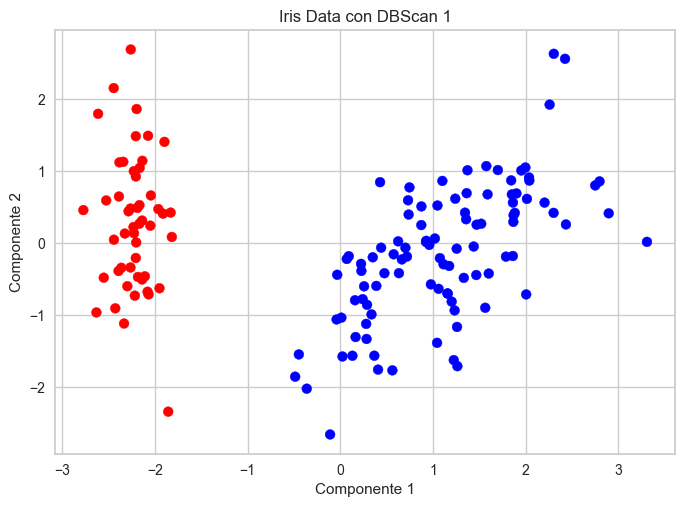

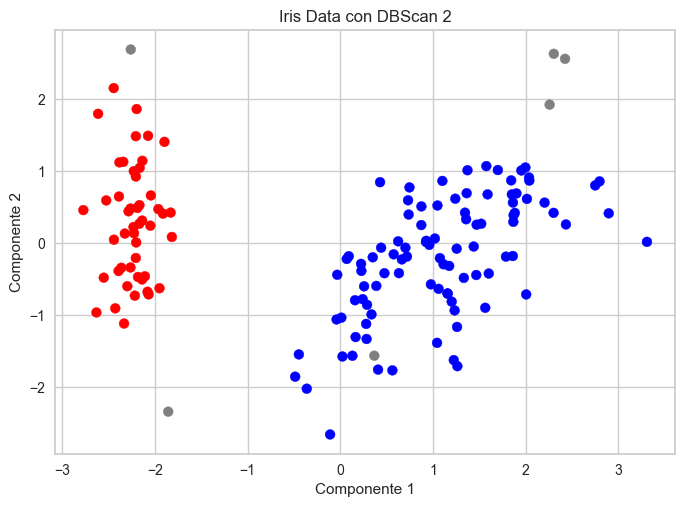

In [41]:
# Visualizacion con las primeras 2 componentes principales 
# Grupos formados con DBScan

plt.scatter(proyecciones1['PC1'], proyecciones1['PC2'], s = 50, c = color_dbs1)
plt.title('Iris Data con DBScan 1')
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

plt.scatter(proyecciones1['PC1'], proyecciones1['PC2'], s = 50, c = color_dbs2)
plt.title('Iris Data con DBScan 2')
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

In [25]:
# ¿Qué se puede concluir al respecto?
# ¿Qué haria usted en esta situación?
# ¿Cuál método (de todos los vistos hasta el momento) utilizaría? 